# Role-aware IAF depth and ordering test

This notebook isolates the IAF layer schedule while keeping the shallow DSS-LVR BNN fixed. The simulation uses the established truth: $n=240$, $p=6$, active predictors $x_0$ and $x_3$, two teacher units, and five fitted hidden units. A single matched MCMC reference is reused by all four VI fits.

The four configurations are:

1. **1 layer, $\tau$ last:** $U\prec V\prec\tau$.
2. **6 layers, all six role permutations:** each permutation of $(U,V,\tau)$ appears once.
3. **4 layers, cyclic:** one complete three-layer cycle plus the next $\tau$-last layer.
4. **6 layers, two three-layer cycles:** $(U\prec V\prec\tau,\ V\prec\tau\prec U,\ \tau\prec U\prec V)$ repeated twice.

All runs use the same data split, initialization seed, normalized-ReQU map, MADE size, optimization budget, and posterior sample size. Within-role coordinate shuffles are deterministic by layer and role, so the comparison changes the role-level schedule rather than introducing uncontrolled permutation noise.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from IPython.display import display

import Python.config as cfg
import Python.utils as ut
import Python.simfun as sim
import Python.model2 as md
import Python.bnn_metric as bm
import Python.bnn_mcmc as mcmc
import Python.bnn_train as train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
print("device:", device)

device: cpu


In [9]:
# Set QUICK=True only to verify that the notebook runs end-to-end.
QUICK = False

flow_specs = {
    "1L tau-last": dict(K_flow=1, iaf_ordering_scheme="cyclic3"),
    "6L six permutations": dict(K_flow=6, iaf_ordering_scheme="six_permutations"),
    "4L cyclic + tau-last": dict(K_flow=4, iaf_ordering_scheme="cyclic3"),
    "6L two 3-layer cycles": dict(K_flow=6, iaf_ordering_scheme="cyclic3"),
}

fit_cfg = dict(
    epochs=2000,
    warmup_epochs=500,
    lr=3e-4,
    R_train=100,
    R_eval=500,
    R_final=5000,
    eval_every=500,
    init_sd=0.5,
    init_loc_jitter=0.05,
    flow_hidden_units=128,
    flow_hidden_layers=2,
    scale_clip=1.5,
    gate_type="normalized_requ",
    gate_scale=1.0,
    iaf_shuffle_within_role=True,
    sampling_timing_repeats=3,
)

mcmc_cfg = dict(
    n_chains=8,
    N=20000,
    burnin=4000,
    thin=1,
    S_max=100,
    print_every=None,
)

if QUICK:
    fit_cfg.update(
        epochs=120,
        warmup_epochs=30,
        R_train=16,
        R_eval=64,
        R_final=256,
        eval_every=60,
        sampling_timing_repeats=1,
        flow_hidden_units=32,
        flow_hidden_layers=1,
    )
    mcmc_cfg.update(n_chains=2, N=160, burnin=40, S_max=40)

In [3]:
X, y, feature_true, unit_true, signal, info = sim.simfun_grouped_bnn(
    n=240,
    p=6,
    active_features=(0, 3),
    n_true_units=2,
    fit_units=5,
    repu_power=None,
    sigma2=1.0,
    target_signal_sd=1.5,
    seed=seed,
    device=device,
)

split_cfg = cfg.SplitConfig(train_frac=0.60, val_frac=0.20, test_frac=0.20, seed=seed + 1000)
indices = ut.make_split(X.shape[0], split_cfg)
splits = ut.split_data(X, y, indices, mode="tensor")
signal_splits = ut.split_data(X, signal, indices, mode="tensor")

print("active features:", info["active_idx"].tolist())

active features: [0, 3]


## Matched MCMC reference

In [10]:
reference_model = md.GroupedBNNVI(
    X=splits["X_train"],
    y=splits["y_train"],
    input_dim=6,
    hidden_dims=(5,),
    out_dim=1,
    selection_mode="feature_group",
    family=info["family"],
    sigma2=info["sigma2"],
    init_sd=0.5,
    K_flow=0,
    flow_type="meanfield",
    gate_type="normalized_requ",
    gate_scale=1.0,
).to(device)

reference = mcmc.run_bnn_mcmc_chains(
    reference_model,
    seed=seed + 5000,
    initial_state="prior",
    **mcmc_cfg,
)
reference_xi = torch.as_tensor(reference["xi_draws"], device=device, dtype=X.dtype)
diagnostics = pd.DataFrame(mcmc.chain_diagnostics(reference["chain_xi_draws"]))
print(f"MCMC: max Rhat={diagnostics.rhat.max():.3f}, min ESS={diagnostics.ess.min():.0f}")

--- MCMC chain 1/8; seed=5123 ---
--- MCMC chain 2/8; seed=6132 ---
--- MCMC chain 3/8; seed=7141 ---
--- MCMC chain 4/8; seed=8150 ---
--- MCMC chain 5/8; seed=9159 ---
--- MCMC chain 6/8; seed=10168 ---
--- MCMC chain 7/8; seed=11177 ---
--- MCMC chain 8/8; seed=12186 ---
MCMC: max Rhat=1.017, min ESS=580


## IAF configurations

In [11]:
runs = {}
for label, spec in flow_specs.items():
    runs[label] = train.train_grouped_bnn(
        X_train=splits["X_train"],
        y_train=splits["y_train"],
        X_eval=splits["X_val"],
        signal_eval=signal_splits["y_val"],
        X_final=splits["X_test"],
        signal_final=signal_splits["y_test"],
        truth=info,
        reference_decoder=reference_model.decoder,
        reference_xi=reference_xi,
        selection_mode="feature_group",
        input_dim=6,
        hidden_dims=(5,),
        out_dim=1,
        family=info["family"],
        sigma2=info["sigma2"],
        flow_type="iaf",
        K_flow=spec["K_flow"],
        iaf_ordering_scheme=spec["iaf_ordering_scheme"],
        flow_seed=seed + 10,
        seed=seed + 10,
        **fit_cfg,
    )

rows = []
for label, out in runs.items():
    s = out["final"]["summary"]
    rows.append({
        "configuration": label,
        "orders": s["iaf_role_orders"],
        "Active SKL": s["active_skl"],
        "Zero JS": s["zero_js"],
        "MSE": s["mse"],
        "R2": s["r2"],
        "AUROC": s["auroc"],
        "AUPRC": s["auprc"],
        "train s": s["train_time_sec"],
        "sample s": s["posterior_sampling_time_sec"],
        "flow params": s["flow_trainable_params"],
        "inverse err": s["flow_max_inverse_error"],
    })

results = pd.DataFrame(rows)
display(results.round(4))

epoch=0001 phase=repr   valMSE=3.91310 valR2=-1.0134
epoch=0500 phase=repr   valMSE=0.04511 valR2=0.9768
epoch=1000 phase=select valMSE=0.02758 valR2=0.9858
epoch=1500 phase=select valMSE=0.04435 valR2=0.9772
epoch=2000 phase=select valMSE=0.03682 valR2=0.9811
epoch=0001 phase=repr   valMSE=4.56581 valR2=-1.3492
epoch=0500 phase=repr   valMSE=0.04167 valR2=0.9786
epoch=1000 phase=select valMSE=0.04256 valR2=0.9781
epoch=1500 phase=select valMSE=0.03295 valR2=0.9830
epoch=2000 phase=select valMSE=0.03217 valR2=0.9834
epoch=0001 phase=repr   valMSE=4.39348 valR2=-1.2605
epoch=0500 phase=repr   valMSE=0.05079 valR2=0.9739
epoch=1000 phase=select valMSE=0.03246 valR2=0.9833
epoch=1500 phase=select valMSE=0.03420 valR2=0.9824
epoch=2000 phase=select valMSE=0.03078 valR2=0.9842
epoch=0001 phase=repr   valMSE=4.56735 valR2=-1.3500
epoch=0500 phase=repr   valMSE=0.04002 valR2=0.9794
epoch=1000 phase=select valMSE=0.03271 valR2=0.9832
epoch=1500 phase=select valMSE=0.03128 valR2=0.9839
epoch=20

,configuration,orders,Active SKL,Zero JS,MSE,R2,AUROC,AUPRC,train s,sample s,flow params,inverse err
0,1L tau-last,U<V<tau,0.1632,0.0221,0.0564,0.9805,1.0,1.0,9.8803,0.0034,35168,0.0
1,6L six permutations,U<V<tau | V<tau<U | tau<U<V | V<U<tau | U<tau<...,0.0228,0.0267,0.0553,0.9809,1.0,1.0,29.1166,0.0111,211008,0.0
2,4L cyclic + tau-last,U<V<tau | V<tau<U | tau<U<V | U<V<tau,0.0599,0.0250,0.0491,0.9830,1.0,1.0,21.3956,0.0078,140672,0.0
3,6L two 3-layer cycles,U<V<tau | V<tau<U | tau<U<V | U<V<tau | V<tau<...,0.0234,0.0311,0.0536,0.9815,1.0,1.0,28.7440,0.0110,211008,0.0


## Joint active-posterior density

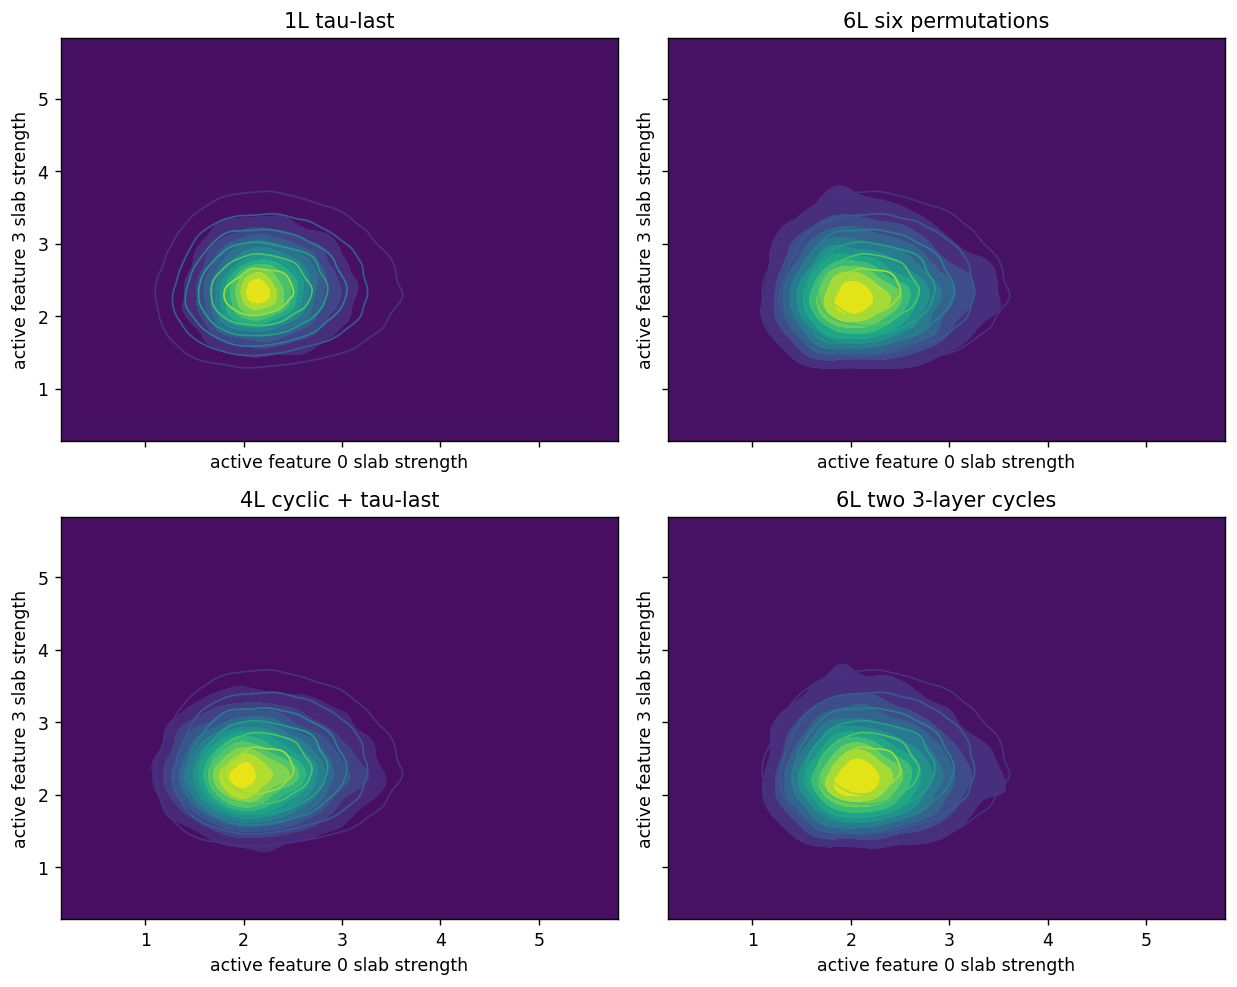

In [12]:
def active_pair_draws(decoder, xi, active_idx=(0, 3)):
    draws = bm.selection_draws(decoder, xi)
    idx = torch.as_tensor(active_idx, device=xi.device, dtype=torch.long)
    jointly_active = draws["active"].index_select(1, idx).all(dim=1)
    return draws["slab_strength"].index_select(1, idx)[jointly_active].detach().cpu().numpy()

mcmc_draws = active_pair_draws(reference_model.decoder, reference_xi)
vi_draws = {
    label: active_pair_draws(out["model"].decoder, out["final"]["xi"])
    for label, out in runs.items()
}

usable = [mcmc_draws] + [x for x in vi_draws.values() if len(x) >= 10]
all_draws = np.vstack(usable)
pad = 0.08 * np.maximum(all_draws.max(axis=0) - all_draws.min(axis=0), 1e-3)
x_grid = np.linspace(all_draws[:, 0].min() - pad[0], all_draws[:, 0].max() + pad[0], 140)
y_grid = np.linspace(all_draws[:, 1].min() - pad[1], all_draws[:, 1].max() + pad[1], 140)
xx, yy = np.meshgrid(x_grid, y_grid)
grid = np.vstack([xx.ravel(), yy.ravel()])
mcmc_kde = gaussian_kde(mcmc_draws.T)(grid).reshape(xx.shape)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, (label, values) in zip(axes.flat, vi_draws.items()):
    if len(values) < 10:
        ax.set_title(f"{label}: insufficient active draws")
        continue
    vi_kde = gaussian_kde(values.T)(grid).reshape(xx.shape)
    ax.contourf(xx, yy, vi_kde, levels=12)
    ax.contour(xx, yy, mcmc_kde, levels=6, linewidths=1.0)
    ax.set_title(label)
    ax.set_xlabel("active feature 0 slab strength")
    ax.set_ylabel("active feature 3 slab strength")

plt.tight_layout()
plt.show()

In [13]:
display(
    diagnostics
    .sort_values("ess")
    .head(15)
)

,variable,mean,sd,rhat,ess,mcse
16,value_16,-0.432288,1.038164,1.012701,579.836030,0.043114
25,value_25,0.343143,0.985896,1.015453,587.393035,0.040679
28,value_28,-0.505300,1.060104,1.011857,599.054002,0.043313
19,value_19,0.357400,1.023503,1.017173,618.244447,0.041163
7,value_7,0.363421,1.022726,1.008244,626.952090,0.040845
4,value_4,-0.426388,1.044438,1.010013,648.806701,0.041004
10,value_10,-0.422268,1.042381,1.008467,650.749229,0.040862
22,value_22,-0.425811,1.038600,1.012255,673.006019,0.040035
1,value_1,0.329614,1.005329,1.008307,674.850278,0.038699
13,value_13,0.328218,0.990755,1.008948,699.048699,0.037472
